<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Liz Multiple Linear Regression

Load data:

In [21]:
# Import Required Packages
import math
import glob
import os
import zipfile
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import holidays
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn import preprocessing
import statsmodels.api as sm
import scipy.stats as stats
from scipy.optimize import curve_fit

In [3]:
# For use in Visual Studio

#Get all part files in order
part_files = sorted(glob.glob("data/NSW/forecastdemand_nsw.csv.zip.part*"))

# Combine them into one ZIP file
with open("data/NSW/forecastdemand_nsw.csv.zip", "wb") as output:
    for part in part_files:
        with open(part, "rb") as pf:
            output.write(pf.read())
print("Zip file reconstructed successfully")

Zip file reconstructed successfully


In [4]:
# Unzip the data files into the data folder

# List of zip files and destination folder
zip_files = [
    "data/NSW/forecastdemand_nsw.csv.zip",
    "data/NSW/temperature_nsw.csv.zip",
    "data/NSW/totaldemand_nsw.csv.zip"
]
destination_folder = "data"

# Unzip each file
for zip_path in zip_files:
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)
        print(f"Extracted: {zip_path} → {destination_folder}")
    except FileNotFoundError:
        print(f"File not found: {zip_path}")
    except zipfile.BadZipFile:
        print(f"Invalid ZIP file: {zip_path}")
    except Exception as e:
        print(f"Error extracting {zip_path}: {e}")


Extracted: data/NSW/forecastdemand_nsw.csv.zip → data
Extracted: data/NSW/temperature_nsw.csv.zip → data
Extracted: data/NSW/totaldemand_nsw.csv.zip → data


In [5]:
# Remove the ZIP file if it exists
zip_path = "data/NSW/forecastdemand_nsw.csv.zip"
try:
    os.remove(zip_path)
    print(f"Removed: {zip_path}")
except FileNotFoundError:
    print(f"File not found (skipped): {zip_path}")
except Exception as e:
    print(f"Error removing {zip_path}: {e}")

# List contents of the 'data' folder with file sizes
data_folder = "data"
try:
    print("\nContents of 'data' folder:")
    for filename in os.listdir(data_folder):
        filepath = os.path.join(data_folder, filename)
        if os.path.isfile(filepath):
            size_kb = os.path.getsize(filepath) / 1024
            print(f"{filename:<40} {size_kb:>10.2f} KB")
except Exception as e:
    print(f"Error listing files in {data_folder}: {e}")


Removed: data/NSW/forecastdemand_nsw.csv.zip

Contents of 'data' folder:
forecastdemand_nsw.csv                    722297.76 KB
temperature_nsw.csv                         6716.26 KB
totaldemand_nsw.csv                         5660.43 KB


In [6]:
# Create dataframes

df_forecast = pd.read_csv('data/forecastdemand_nsw.csv')
df_temperature = pd.read_csv('data/temperature_nsw.csv')
df_totaldemand = pd.read_csv('data/totaldemand_nsw.csv')

In [7]:
# Remove unzipped files to save space

# List of files to remove
files_to_remove = [
    "data/forecastdemand_nsw.csv",
    "data/temperature_nsw.csv",
    "data/totaldemand_nsw.csv"
]

# Remove each file if it exists
for file_path in files_to_remove:
    try:
        os.remove(file_path)
        print(f"Removed: {file_path}")
    except FileNotFoundError:
        print(f"File not found (skipped): {file_path}")
    except Exception as e:
        print(f"Error removing {file_path}: {e}")


Removed: data/forecastdemand_nsw.csv
Removed: data/temperature_nsw.csv
Removed: data/totaldemand_nsw.csv


Add additional data:

In [8]:
# Get NSW public holidays
nsw_holidays = holidays.country_holidays('AU', subdiv='NSW')

Convert 30 minute data points into Daily data points:

In [25]:
# Convert all to pandas datetime and normalize to day-level

# Convert DATETIME column to pandas datetime
def convert_datetime(df):
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
    return df

# Apply conversion to all datasets
df_forecast = convert_datetime(df_forecast)
df_temperature = convert_datetime(df_temperature)
df_totaldemand = convert_datetime(df_totaldemand)


# Group forecast by DATETIME and average
df_forecast_avg = df_forecast.groupby('DATETIME', as_index=False)['FORECASTDEMAND'].mean()

# Merge all DataFrames on 'DATETIME'
df_merged = df_forecast_avg.merge(df_totaldemand[['DATETIME', 'TOTALDEMAND']], on='DATETIME', how='left') \
                           .merge(df_temperature[['DATETIME', 'TEMPERATURE']], on='DATETIME', how='left')

# Resample by day and calculate min, max, and mean for TEMPERATURE

# Set 'DATETIME' as index before resampling
df_merged = df_merged.set_index('DATETIME')

df_daily = df_merged.resample('D').agg({
    'TEMPERATURE': ['min', 'max', 'mean'],
    'FORECASTDEMAND': ['min', 'max', 'mean'],
    'TOTALDEMAND': ['min', 'max', 'mean']
})

# Create binary features for extreme temperature events
df_daily['extreme_hot'] = (df_daily['TEMPERATURE']['max'] > 35).astype(bool)
df_daily['extreme_cold'] = (df_daily['TEMPERATURE']['min'] < 5).astype(bool)


print(df_daily.head())




           TEMPERATURE                  FORECASTDEMAND                \
                   min   max       mean            min           max   
DATETIME                                                               
2010-01-01        22.1  28.8  25.185417    6005.058788   9064.004035   
2010-01-02        22.2  29.4  24.795833    5889.610380   9103.866604   
2010-01-03        17.9  21.5  19.462500    5887.778481   8390.429130   
2010-01-04        17.9  23.9  20.847917    6180.682436  10032.460400   
2010-01-05        15.4  27.7  22.660417    6300.561026  10685.659636   

                        TOTALDEMAND                        extreme_hot  \
                   mean         min       max         mean               
DATETIME                                                                 
2010-01-01  7723.688982     6198.61   8883.98  7801.352917       False   
2010-01-02  7804.668591     6140.82   9294.07  8017.459792       False   
2010-01-03  7491.520488     6059.53   8247.61  7399.8

Create Model Features:

In [10]:
# Create feature matrix X with multiple columns
X = pd.DataFrame({
    'datetime': df_daily.index,
    'temp_mean': df_daily['TEMPERATURE']['mean'],
    'temp_min': df_daily['TEMPERATURE']['min'],
    'temp_max': df_daily['TEMPERATURE']['max'],
    'extreme_hot': df_daily['extreme_hot'],
    'extreme_cold': df_daily['extreme_cold']
})
# Target variable
y= df_daily['TOTALDEMAND']['mean'].values


# Rolling averages (3-day mean temperature)
X['temp_rolling3'] = X['temp_mean'].rolling(window=3, min_periods=1).mean()
X['temp_diff'] = X['temp_mean'] - X['temp_mean'].shift(1)
# Add day of week and month - feature engineering
X['dayofweek'] = X['datetime'].dt.dayofweek
X['month'] = X['datetime'].dt.month
X['is_holiday'] = X['datetime'].dt.date.apply(lambda x: bool(x in nsw_holidays))

# Create lagged forecast demand feature
df_daily['forecast_24H'] = df_daily['FORECASTDEMAND']['mean'].shift(1)



# Add to feature matrix X
X['forecast_24H'] = df_daily['forecast_24H'].values




# One-hot encode day of week, month
X = pd.get_dummies(X, columns=['dayofweek', 'month'], drop_first=False)

# Feature matrix X and target y
feature_cols = ['temp_mean', 'temp_min', 'temp_max', 'temp_rolling3', 'temp_diff', 'forecast_24H', 'extreme_hot', 'extreme_cold', 'is_holiday'] + \
               [col for col in X.columns if col.startswith('dayofweek_') or col.startswith('month_')]
X = X[feature_cols].fillna(0)

# Rename day and month columns for better clarity
# Mapping dictionaries
day_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

month_map = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Rename columns
X.rename(columns={
    **{f'dayofweek_{i}': day_map[i] for i in day_map},
    **{f'month_{i}': month_map[i] for i in month_map}
}, inplace=True)

# Remove first row to account for previous 24H forecast demand 
X = X.iloc[1:].reset_index(drop=True)
y = y[1:]


print(X.head())
print(X.dtypes)

print(y[:5])

print(X['forecast_24H'].describe())
print(X['forecast_24H'].value_counts())


   temp_mean  temp_min  temp_max  temp_rolling3  temp_diff  forecast_24H  \
0  24.795833      22.2      29.4      24.990625  -0.389583   7723.688982   
1  19.462500      17.9      21.5      23.147917  -5.333333   7804.668591   
2  20.847917      17.9      23.9      21.702083   1.385417   7491.520488   
3  22.660417      15.4      27.7      20.990278   1.812500   8592.014274   
4  22.695833      20.3      25.6      22.068056   0.035417   8907.999454   

   extreme_hot  extreme_cold  is_holiday  Monday  ...  March  April    May  \
0        False         False       False   False  ...  False  False  False   
1        False         False       False   False  ...  False  False  False   
2        False         False       False    True  ...  False  False  False   
3        False         False       False   False  ...  False  False  False   
4        False         False       False   False  ...  False  False  False   

    June   July  August  September  October  November  December  
0  False

Conduct some exploratory data analysis:

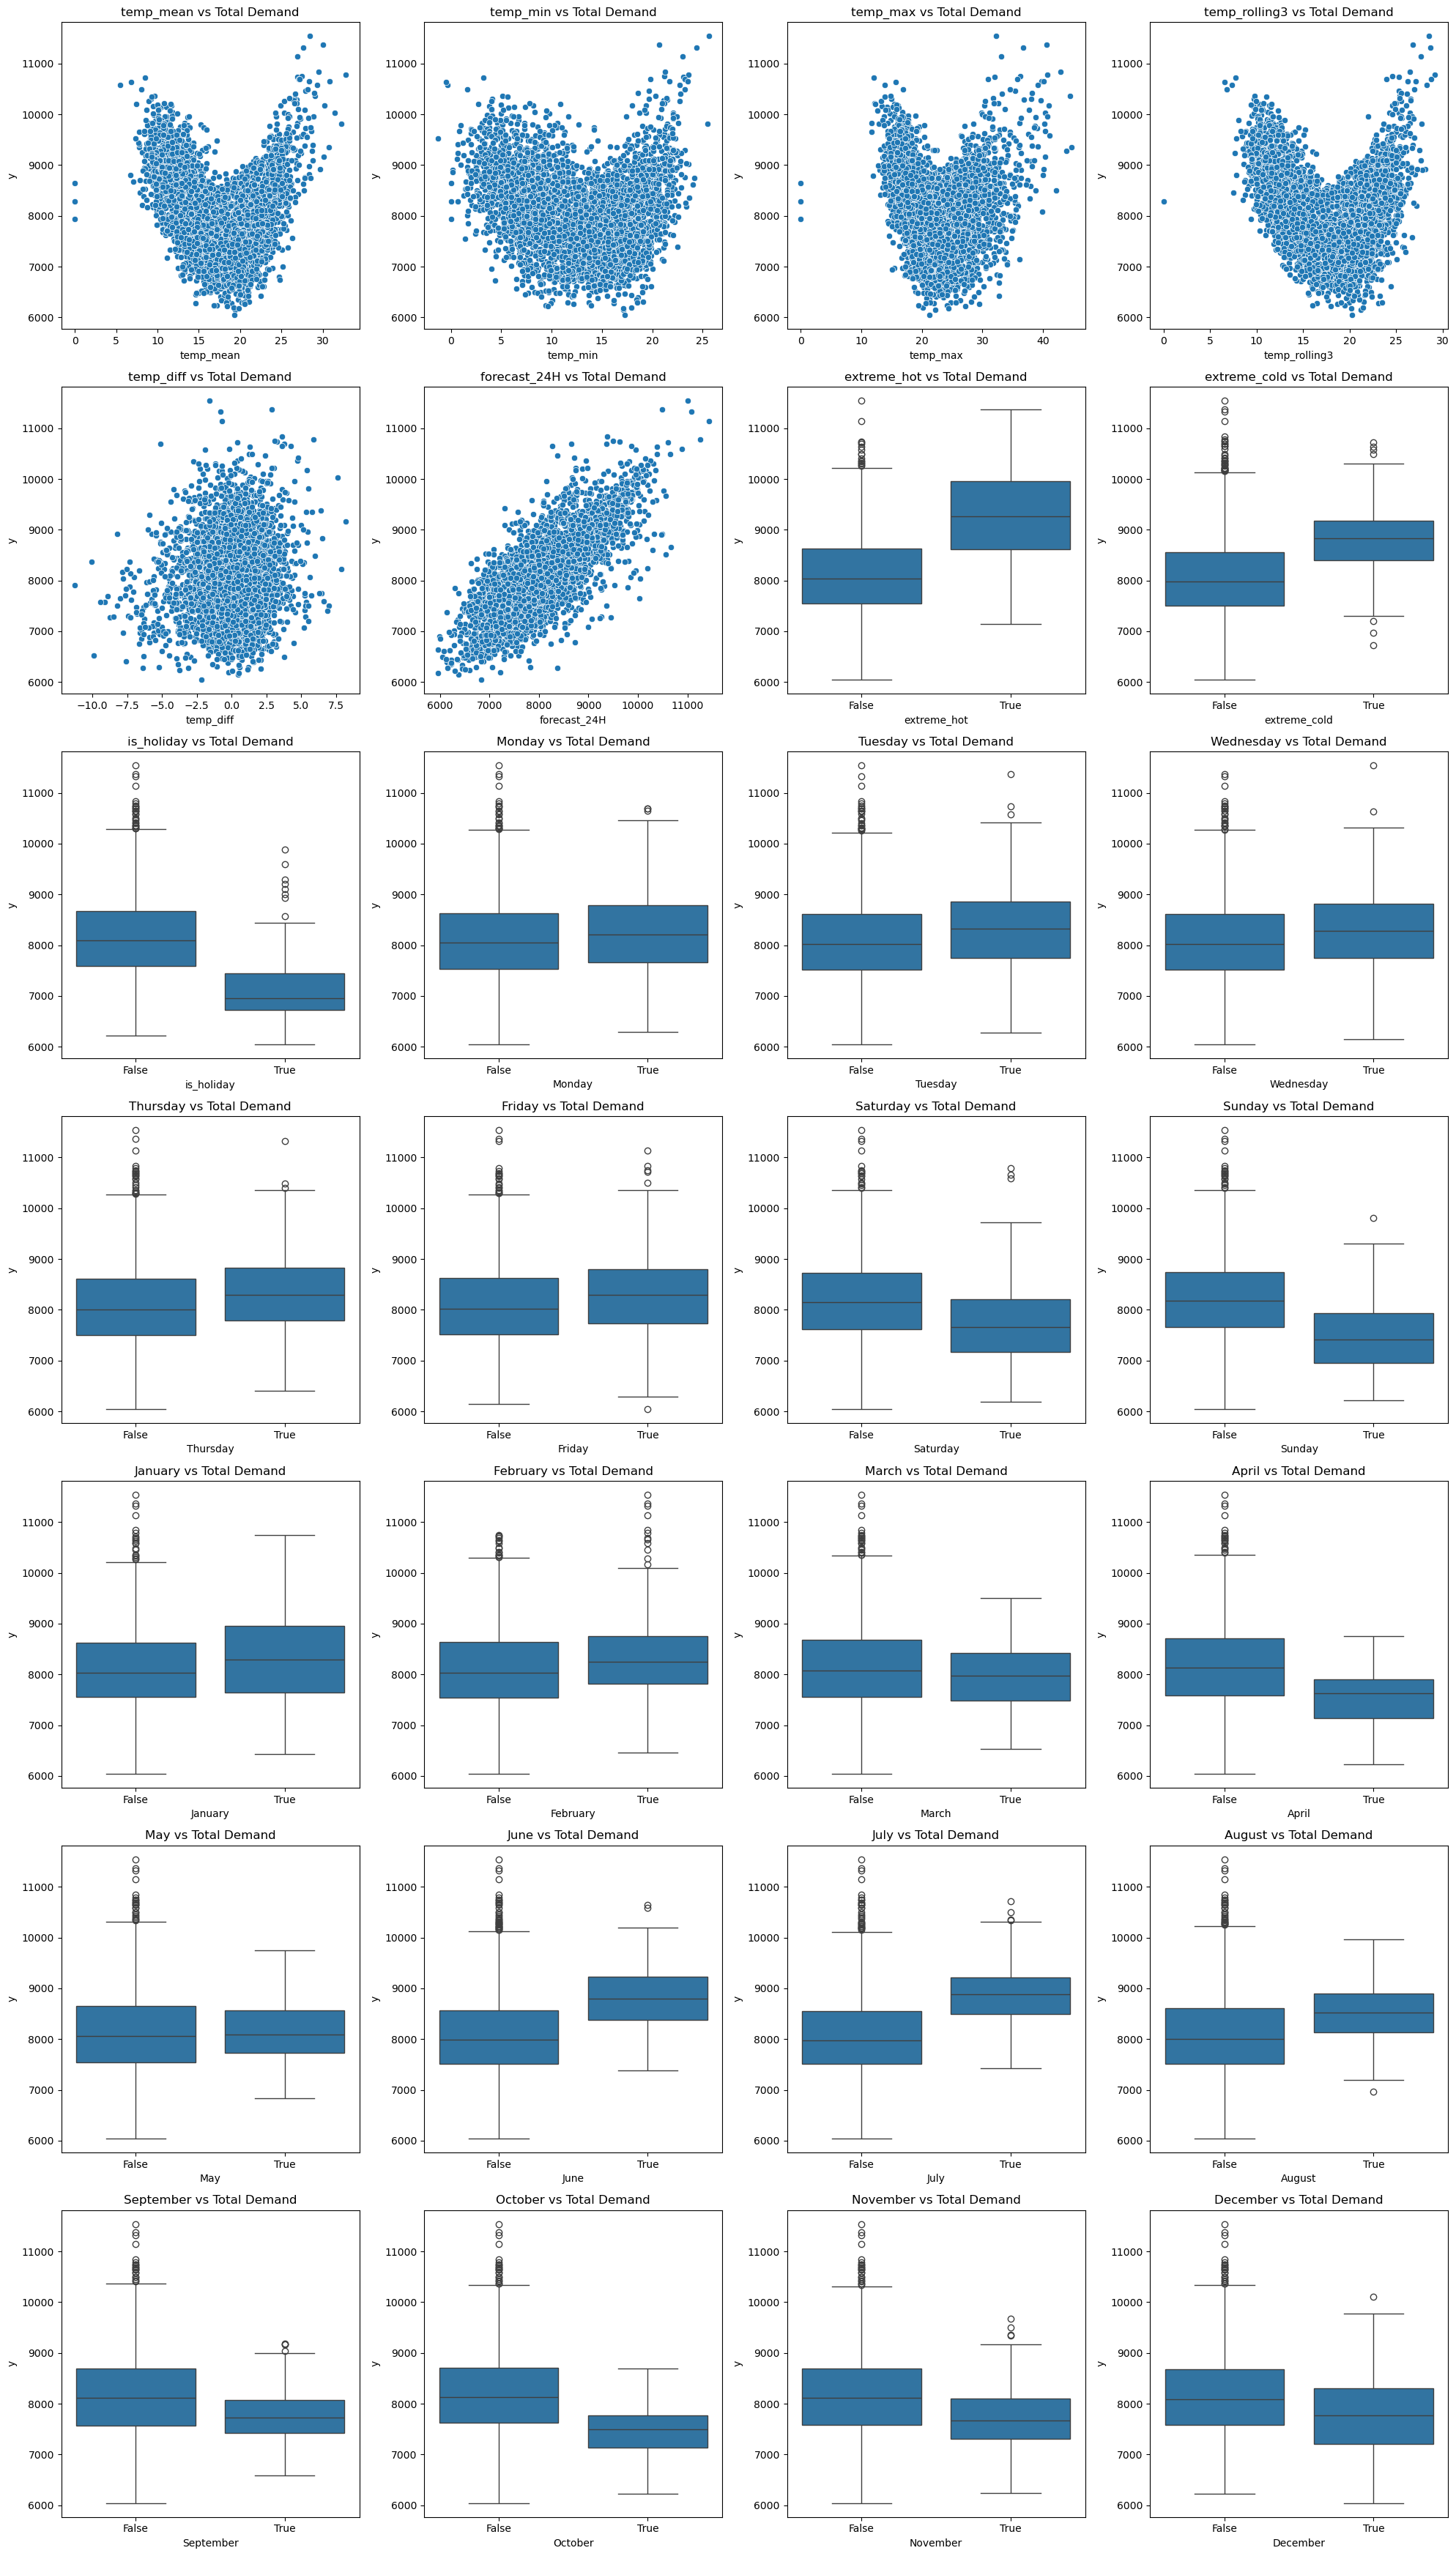

In [11]:
# Plot independent variables versus dependant variable

# Define float and boolean/categorical columns
float_cols = X.columns[:6]
bool_cols = X.columns[6:29]
all_cols = list(float_cols) + list(bool_cols)

# Total number of plots
n_plots = len(all_cols)

# Grid size
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Plot each feature against y
for i, col in enumerate(all_cols):
    ax = axes[i]
    if col in float_cols:
        sns.scatterplot(x=X[col], y=y, ax=ax)
    else:
        sns.boxplot(x=X[col], ax=ax, y=y)
    ax.set_title(f'{col} vs Total Demand')
    ax.set_xlabel(col)
    ax.set_ylabel('y')

# Hide unused subplots
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




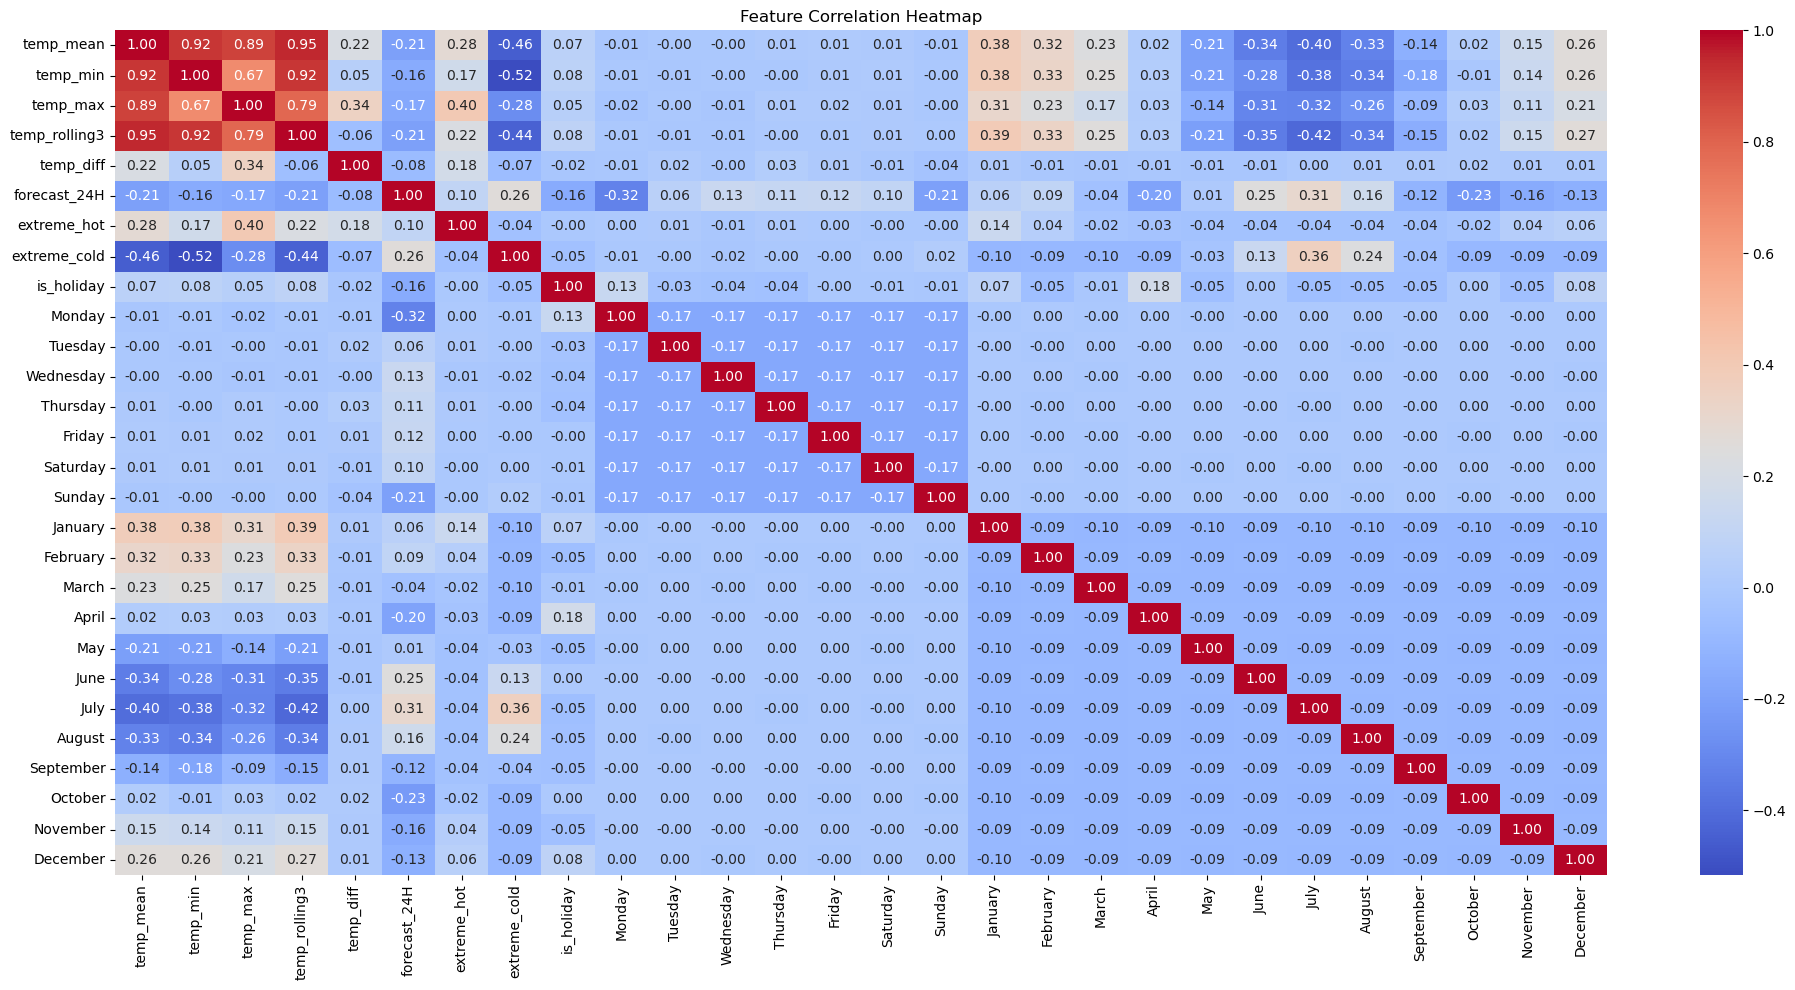

In [12]:
# Check Correlation Matrix

plt.figure(figsize=(20, 10))  
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()



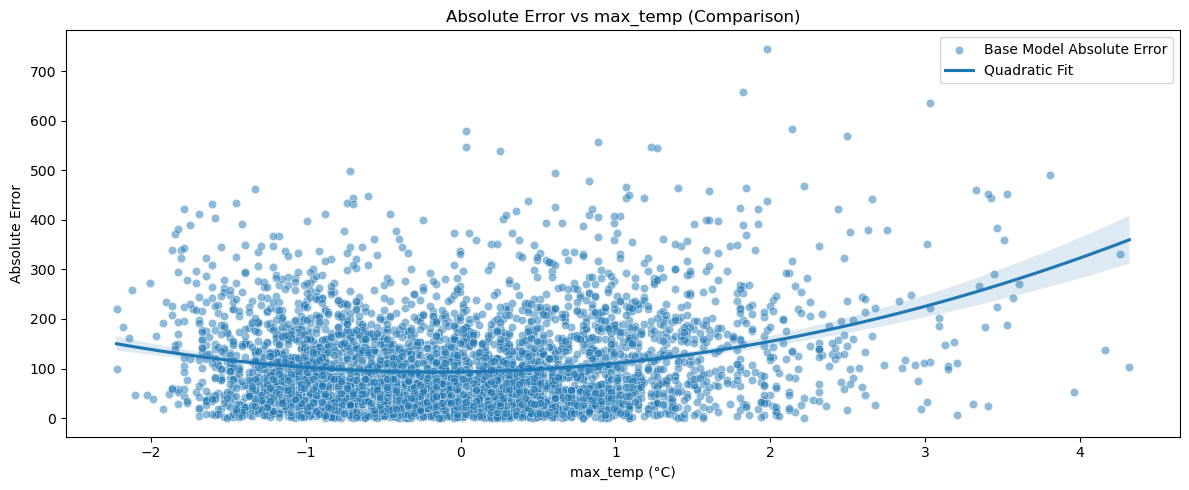

In [13]:
# Review current performance of base model "Forecast Demand"

# Absolute Error

df_daily.replace([np.inf, -np.inf], np.nan).dropna()


x = df_daily['TEMPERATURE']['max']
y_base = np.asarray(abs(df_daily['TOTALDEMAND'] - df_daily['FORECASTDEMAND'])).flatten()


# Standardize x
x_mean = x.mean()
x_std = x.std() or 1.0  # Avoid division by zero
x_scaled = (x - x_mean) / x_std
x_flat = np.asarray(x_scaled).flatten()


# Plot 
plt.figure(figsize=(12, 5))

sns.scatterplot(x=x_flat, y=y_base, alpha=0.5, label = 'Base Model Absolute Error')
sns.regplot(x=x_flat, y=y_base, scatter=False, order=2, label = 'Quadratic Fit')  # quadratic fit

# Labels and legend
plt.title("Absolute Error vs max_temp (Comparison)")
plt.xlabel("max_temp (°C)")
plt.ylabel("Absolute Error")
plt.legend()
plt.tight_layout()
plt.show()



Mulitple Linear Regression:

In [14]:
# Create train and test dataset (70/30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create linear regression model
model = LinearRegression()

# Fit the model
model.fit(X_train,y_train)

# Make predictions
y_pred = model.predict(X_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred))
print(
  'R_squared : ', r2_score(y_test, y_pred))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Display
print(coef_table[['Feature', 'Coefficient']])



mean_squared_error :  92167.90410396025
mean_absolute_error :  221.99415627938728
R_squared :  0.8526370617760941
          Feature  Coefficient
0       temp_mean    34.769500
1        temp_min     3.600200
2        temp_max    -5.829506
3   temp_rolling3   -29.541789
4       temp_diff    32.460576
5    forecast_24H     0.764754
6     extreme_hot   599.552591
7    extreme_cold   148.645245
8      is_holiday  -569.833721
9          Monday   641.400320
10        Tuesday   144.110284
11      Wednesday     1.577978
12       Thursday    46.646964
13         Friday    14.669697
14       Saturday  -544.063946
15         Sunday  -304.341297
16        January    91.013318
17       February   -22.919134
18          March   -76.133745
19          April   -32.903986
20            May    32.354411
21           June   196.706968
22           July   122.510568
23         August    67.861822
24      September  -102.348327
25        October  -127.254681
26       November   -93.135286
27       December 

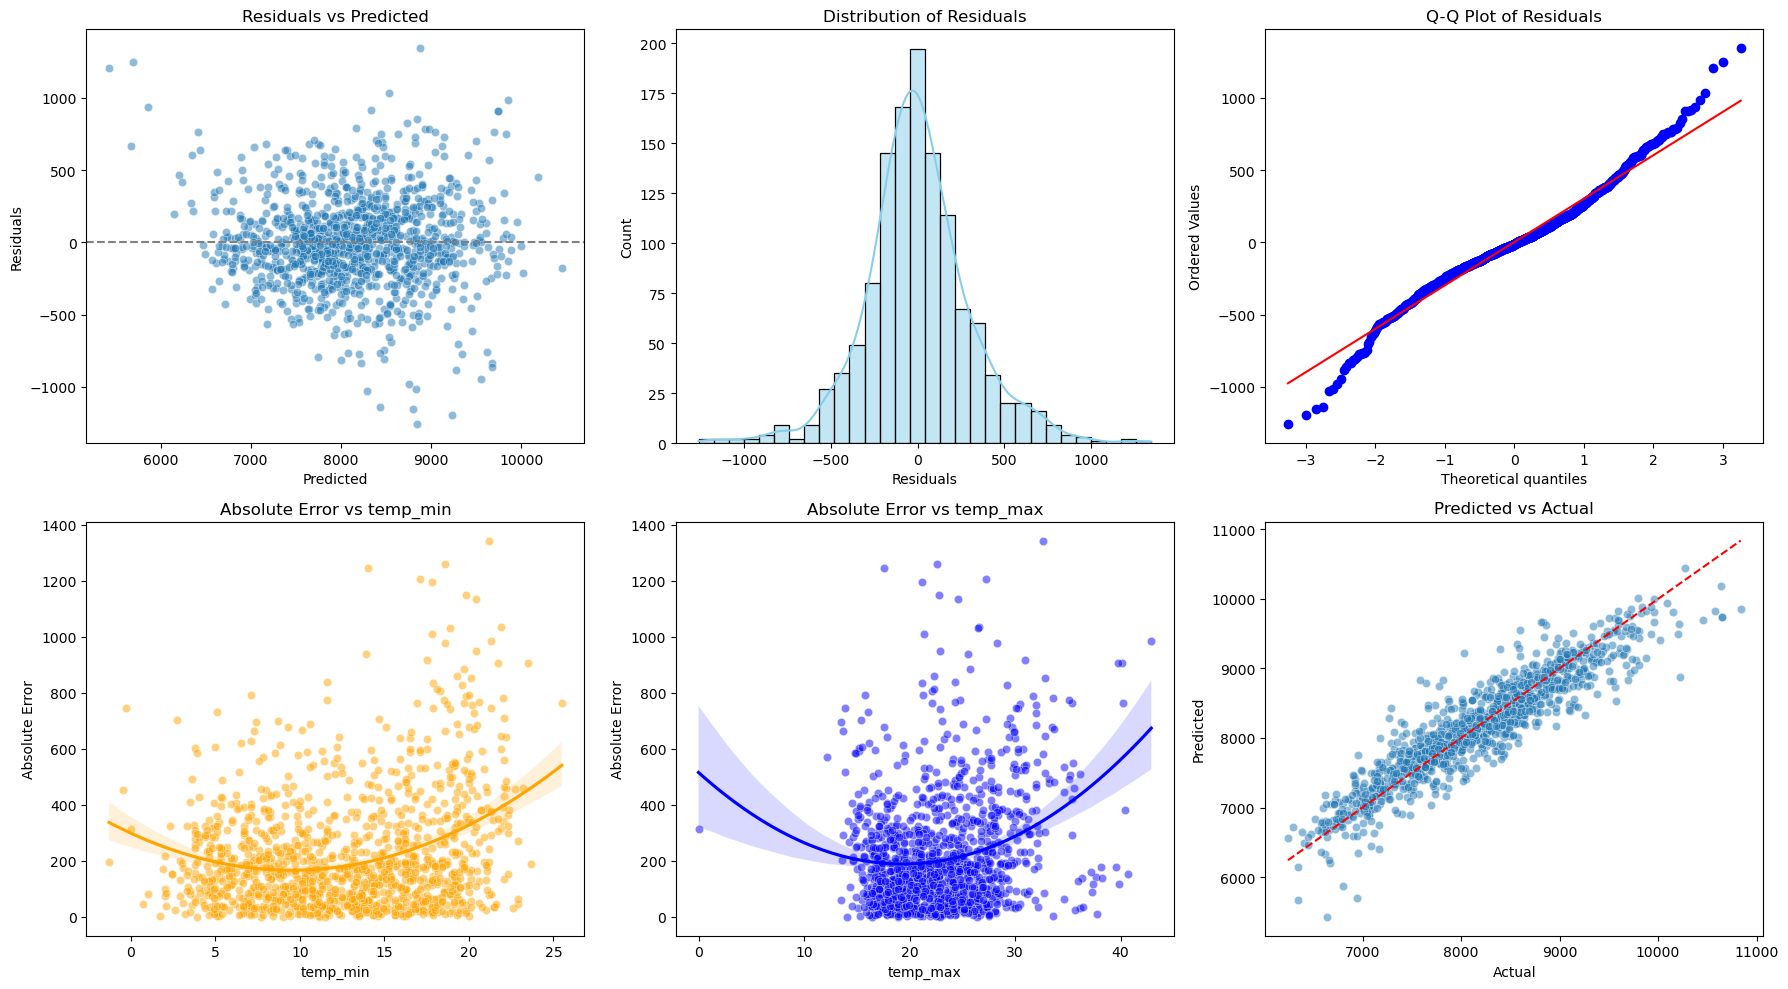

In [38]:
# Evaluation Plots

residuals = y_test - y_pred
absolute_error = np.abs(residuals)

# Create a grid of plots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 0], alpha=0.5)
axes[0, 0].axhline(0, color='gray', linestyle='--')
axes[0, 0].set_title('Residuals vs Predicted')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Residuals')

# 2. Histogram of Residuals
sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].set_xlabel('Residuals')

# 3. Q-Q Plot of Residuals
stats.probplot(residuals, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot of Residuals')

# 4. Absolute Error vs temp_min
sns.scatterplot(x=X_test['temp_min'], y=absolute_error, ax=axes[1, 0], alpha=0.5, color='orange')
sns.regplot(x=X_test['temp_min'], y=absolute_error, ax=axes[1, 0], scatter=False, order=2, color='orange')
axes[1, 0].set_title('Absolute Error vs temp_min')
axes[1, 0].set_xlabel('temp_min')
axes[1, 0].set_ylabel('Absolute Error')

# 5. Absolute Error vs temp_max
sns.scatterplot(x=X_test['temp_max'], y=absolute_error, ax=axes[1, 1], alpha=0.5, color='blue')
sns.regplot(x=X_test['temp_max'], y=absolute_error, ax=axes[1, 1], scatter=False, order=2, color='blue')
axes[1, 1].set_title('Absolute Error vs temp_max')
axes[1, 1].set_xlabel('temp_max')
axes[1, 1].set_ylabel('Absolute Error')

# 6. Predicted vs Actual
sns.scatterplot(x=y_test, y=y_pred, ax=axes[1, 2], alpha=0.5)
axes[1, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1, 2].set_title('Predicted vs Actual')
axes[1, 2].set_xlabel('Actual')
axes[1, 2].set_ylabel('Predicted')

plt.tight_layout()
plt.show()





Multiple Linear Regression Model Using Recursive Feature Elimination:

In [16]:
# Fit RFE
rfe = RFE(model, n_features_to_select=10, step=0.5)
rfe.fit(X_train,y_train)

# Create DataFrame of rankings
rfe_df = pd.DataFrame({
    'Feature': X_train.columns,
    'RFE_Rank': rfe.ranking_
}).sort_values(by='RFE_Rank')  

# Make predictions
y_pred2 = rfe.predict(X_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred2))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred2))
print(
  'R_squared : ', r2_score(y_test, y_pred2))

# Print Coefficient table

# Get selected features and their coefficients
selected_features = X.columns[rfe.support_]
selected_coefs = model.coef_[rfe.support_]


# Create a DataFrame of coefficients
coef_table2 = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': selected_coefs
})

# Display
print(coef_table2[['Feature', 'Coefficient']])


# Feature Importance 
rfe_table = rfe_df.sort_values(by='RFE_Rank')
print("\n📋 Feature Importance via RFE Ranking:\n")
print(rfe_table.to_string(index=False))


mean_squared_error :  310306.0837891703
mean_absolute_error :  440.89444626891
R_squared :  0.5038661592613902
        Feature  Coefficient
0   extreme_hot   599.552591
1  extreme_cold   148.645245
2    is_holiday  -569.833721
3      Saturday  -544.063946
4        Sunday  -304.341297
5          June   196.706968
6          July   122.510568
7     September  -102.348327
8       October  -127.254681
9      November   -93.135286

📋 Feature Importance via RFE Ranking:

      Feature  RFE_Rank
   is_holiday         1
      October         1
    September         1
       Sunday         1
         July         1
         June         1
  extreme_hot         1
 extreme_cold         1
     Saturday         1
     November         1
      January         2
      Tuesday         2
        March         2
       Monday         2
     February         3
          May         3
        April         3
       August         3
    temp_mean         3
       Friday         3
     Thursday         3
  

Polynomial Regression Model:

In [17]:
# 2nd Degree Polynomial

# Create Polynomial Features
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2_train = poly2.fit_transform(X_train)
X_poly2_test = poly2.fit_transform(X_test)
feature_names = poly2.get_feature_names_out(X_train.columns)

# Fit the model
poly2_model = model.fit(X_poly2_train, y_train)

# Make predictions
y_pred3 = poly2_model.predict(X_poly2_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred3))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred3))
print(
  'R_squared : ', r2_score(y_test, y_pred3))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table3 = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': poly2_model.coef_
})

# Display
print(coef_table3[['Feature', 'Coefficient']])

mean_squared_error :  44322.01388247835
mean_absolute_error :  154.95248727588523
R_squared :  0.9291356111737588
               Feature  Coefficient
0            temp_mean  -375.260864
1             temp_min    22.882707
2             temp_max   -32.898317
3        temp_rolling3   434.236521
4            temp_diff   -85.471620
..                 ...          ...
429   October November     0.000000
430   October December     0.000000
431         November^2  -443.808679
432  November December     0.000000
433         December^2  -360.282106

[434 rows x 2 columns]


In [18]:
# 3rd Degree Polynomial

# Create Polynomial Features
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3_train = poly3.fit_transform(X_train)
X_poly3_test = poly3.fit_transform(X_test)
feature_names3 = poly3.get_feature_names_out(X_train.columns)

# Fit the model
poly3_model = model.fit(X_poly3_train, y_train)

# Make predictions
y_pred4 = poly3_model.predict(X_poly3_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred4))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred4))
print(
  'R_squared : ', r2_score(y_test, y_pred4))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table4 = pd.DataFrame({
    'Feature': feature_names3,
    'Coefficient': poly3_model.coef_
})

# Display
print(coef_table4[['Feature', 'Coefficient']])

mean_squared_error :  125739.3258425153
mean_absolute_error :  219.91831349458482
R_squared :  0.7989612904124833
                  Feature  Coefficient
0               temp_mean -1416.673034
1                temp_min  -231.802441
2                temp_max   280.167543
3           temp_rolling3  1245.253412
4               temp_diff -1276.035688
...                   ...          ...
4489   October December^2     0.000000
4490           November^3 -5058.666431
4491  November^2 December     0.000000
4492  November December^2     0.000000
4493           December^3 -3520.230217

[4494 rows x 2 columns]


2nd Degree Polynomial Lasso Regression

In [19]:
# Lasso Regression Model
model2 = make_pipeline(StandardScaler(), Lasso(alpha=0.9, max_iter=100000))

# Fit the model
poly2_lasso = model2.fit(X_poly2_train, y_train)

# Make predictions
y_pred5 = poly2_lasso.predict(X_poly2_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred5))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred5))
print(
  'R_squared : ', r2_score(y_test, y_pred5))

# Print Coefficient table
# Create a DataFrame of coefficients
lasso = model2.named_steps['lasso']

coef_table5 = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso.coef_,
    'Abs_Coef' : np.abs(lasso.coef_)
}).sort_values(by='Abs_Coef', ascending=False)


# Display
print(coef_table5[['Feature', 'Coefficient']])




mean_squared_error :  46850.111078242524
mean_absolute_error :  159.62033918011605
R_squared :  0.9250935551619044
                   Feature  Coefficient
5             forecast_24H   471.661161
30      temp_mean temp_max   331.579440
28             temp_mean^2   283.093487
2                 temp_max  -247.413602
158         forecast_24H^2   234.454316
..                     ...          ...
216       extreme_cold May     0.000000
215     extreme_cold April     0.000000
214     extreme_cold March     0.000000
213  extreme_cold February     0.000000
433             December^2     0.000000

[434 rows x 2 columns]


Model Evaluation:

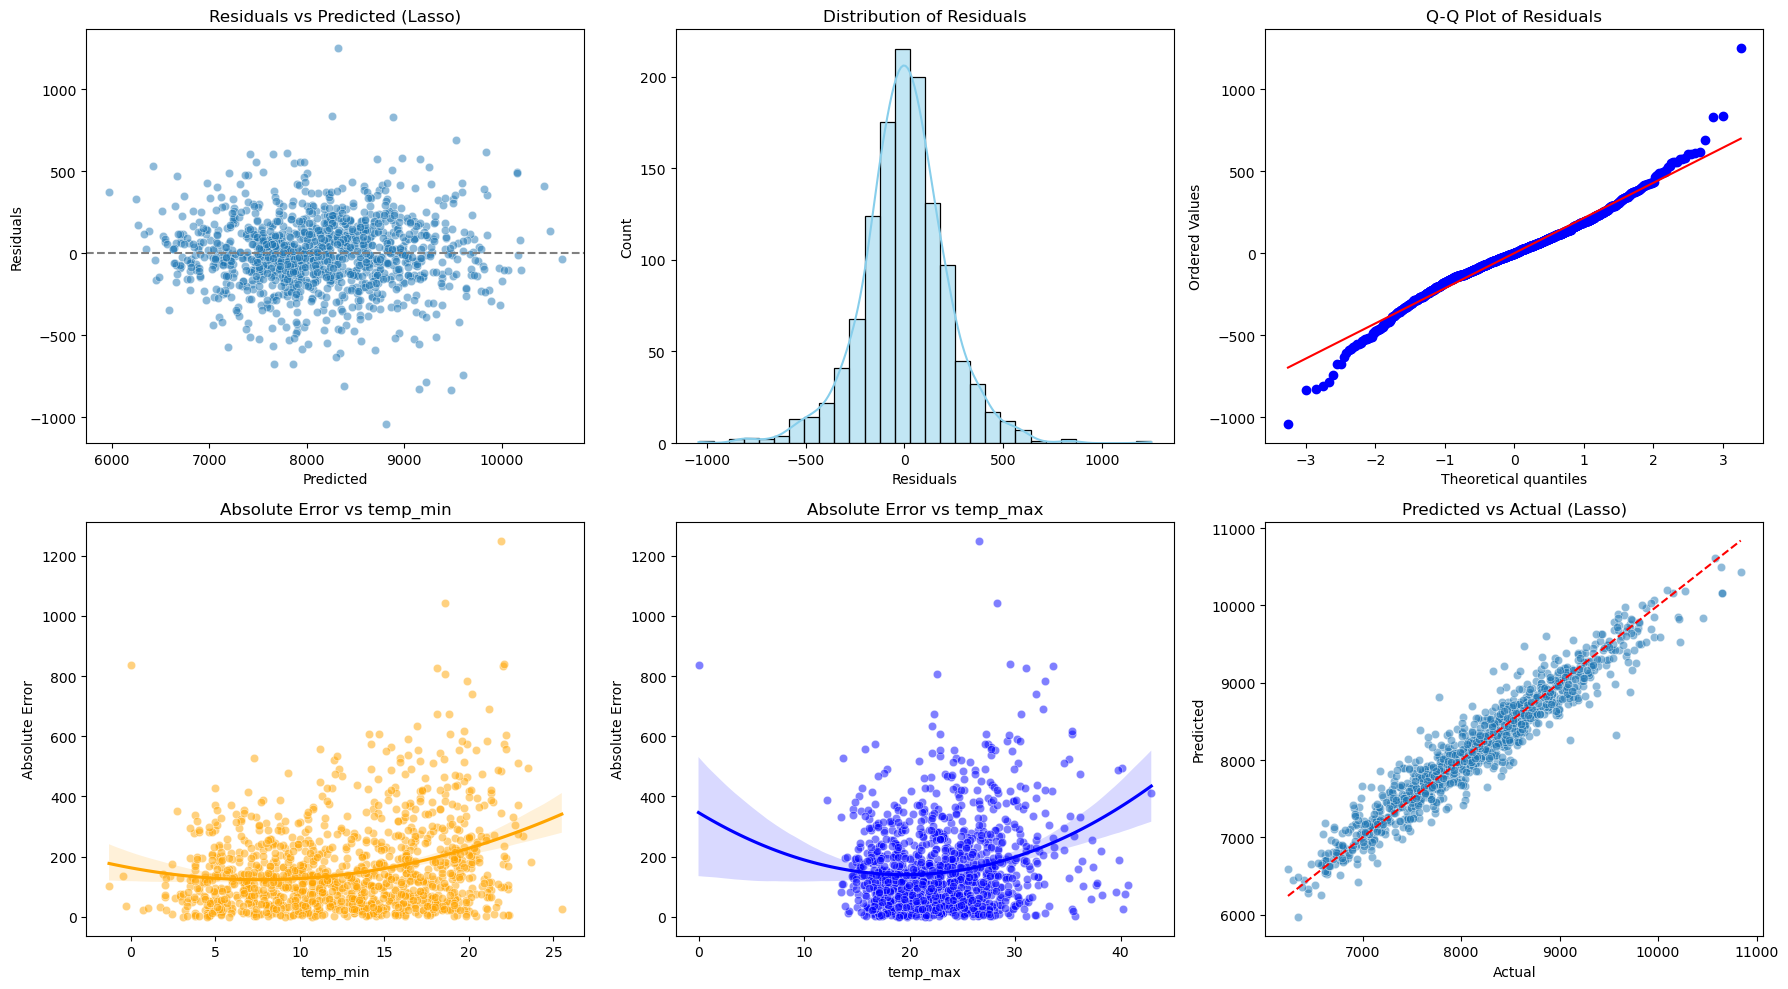

In [39]:
# Evaluation Plots

# Residuals and absolute error for Lasso predictions
residuals_2 = y_test - y_pred5
absolute_error = np.abs(residuals_2)

# Create a grid of plots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Residuals vs Predicted
sns.scatterplot(x=y_pred5, y=residuals_2, ax=axes[0, 0], alpha=0.5)
axes[0, 0].axhline(0, color='gray', linestyle='--')
axes[0, 0].set_title('Residuals vs Predicted (Lasso)')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Residuals')

# 2. Histogram of Residuals
sns.histplot(residuals_2, bins=30, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].set_xlabel('Residuals')

# 3. Q-Q Plot of Residuals
stats.probplot(residuals_2, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot of Residuals')

# 4. Absolute Error vs temp_min
sns.scatterplot(x=X_test['temp_min'], y=absolute_error, ax=axes[1, 0], alpha=0.5, color='orange')
sns.regplot(x=X_test['temp_min'], y=absolute_error, ax=axes[1, 0], scatter=False, order=2, color='orange')
axes[1, 0].set_title('Absolute Error vs temp_min')
axes[1, 0].set_xlabel('temp_min')
axes[1, 0].set_ylabel('Absolute Error')

# 5. Absolute Error vs temp_max
sns.scatterplot(x=X_test['temp_max'], y=absolute_error, ax=axes[1, 1], alpha=0.5, color='blue')
sns.regplot(x=X_test['temp_max'], y=absolute_error, ax=axes[1, 1], scatter=False, order=2, color='blue')
axes[1, 1].set_title('Absolute Error vs temp_max')
axes[1, 1].set_xlabel('temp_max')
axes[1, 1].set_ylabel('Absolute Error')

# 6. Predicted vs Actual
sns.scatterplot(x=y_test, y=y_pred5, ax=axes[1, 2], alpha=0.5)
axes[1, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1, 2].set_title('Predicted vs Actual (Lasso)')
axes[1, 2].set_xlabel('Actual')
axes[1, 2].set_ylabel('Predicted')

plt.tight_layout()
plt.show()


Run model over full data set:

In [29]:
# Assign full dataset
X_poly2 = poly2.fit_transform(X)


# Make predictions
y_pred_full = poly2_lasso.predict(X_poly2)



In [32]:
# Calculate Improvement from Base Model Performance

# Base model predictions (from df_daily)

# Align forecast demand with y_test
forecast_base = df_daily['FORECASTDEMAND']['max']
y_base = df_daily['TOTALDEMAND']['max'] 
print(forecast_base)

# Metrics for base forecast
mae_base = mean_absolute_error(y_base, forecast_base)
rmse_base = math.sqrt(mean_squared_error(y_base, forecast_base))
r2_base = r2_score(y_base, forecast_base)

# Metrics for MLR model
mae_mlr = mean_absolute_error(y, y_pred_full)
rmse_mlr = math.sqrt(mean_squared_error(y, y_pred_full))
r2_mlr = r2_score(y, y_pred_full)

# Print comparison
print("🔍 Performance Comparison")
print(f"Base Forecast → MAE: {mae_base:.2f}, RMSE: {rmse_base:.2f}, R²: {r2_base:.4f}")
print(f"MLR Model     → MAE: {mae_mlr:.2f}, RMSE: {rmse_mlr:.2f}, R²: {r2_mlr:.4f}")


#calculate improvement
mae_improvement = mae_base - mae_mlr
rmse_improvement = rmse_base - rmse_mlr
r2_improvement = r2_mlr - r2_base
print(f"\nMAE improvement: {mae_improvement:.1f} MW ({mae_improvement/mae_base*100:.1f}%)")
print(f"RMSE improvement: {rmse_improvement:.1f} MW ({rmse_improvement/rmse_base*100:.1f}%)")
print(f"R² improvement: {r2_improvement:.3f} ({r2_improvement/r2_base*100:.1f}%)")

DATETIME
2010-01-01     9064.004035
2010-01-02     9103.866604
2010-01-03     8390.429130
2010-01-04    10032.460400
2010-01-05    10685.659636
                  ...     
2021-03-14     8010.395000
2021-03-15     8415.235082
2021-03-16     8419.192000
2021-03-17     8367.849153
2021-03-18     6961.076901
Freq: D, Name: max, Length: 4095, dtype: float64
🔍 Performance Comparison
Base Forecast → MAE: 181.43, RMSE: 243.92, R²: 0.9586
MLR Model     → MAE: 154.35, RMSE: 211.08, R²: 0.9301

MAE improvement: 27.1 MW (14.9%)
RMSE improvement: 32.8 MW (13.5%)
R² improvement: -0.028 (-3.0%)


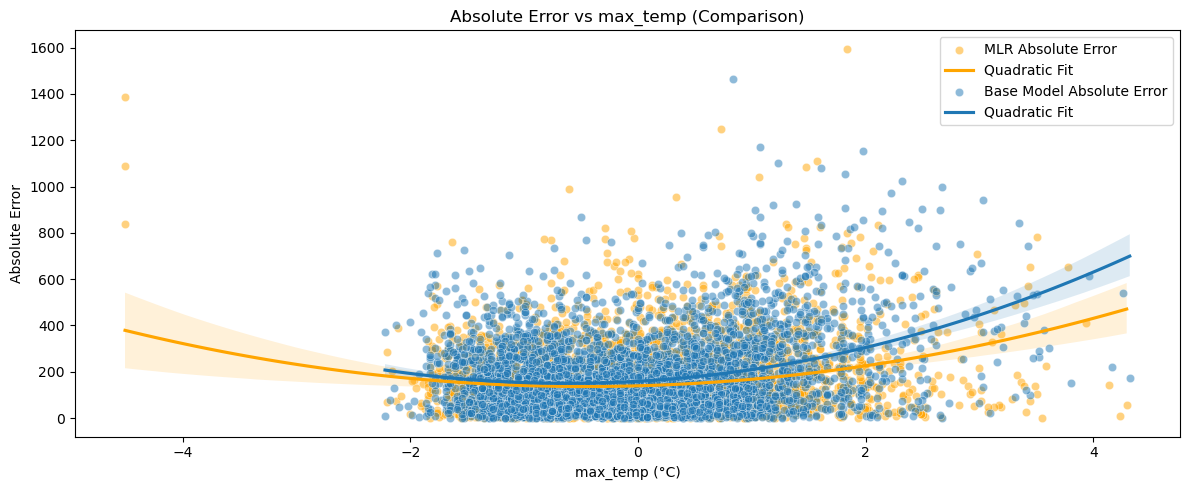

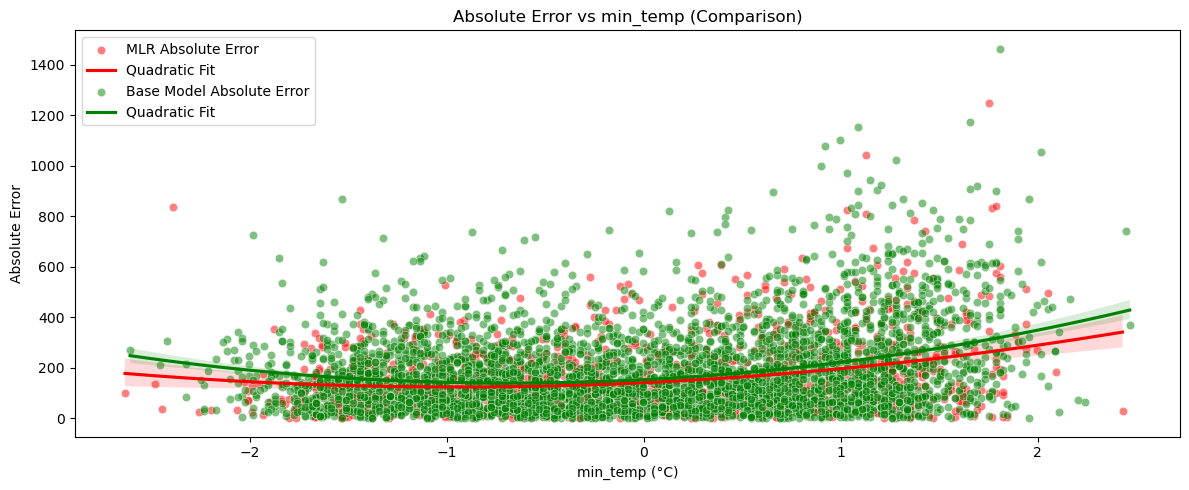

In [33]:
# Absolute Error versus Max Temp

df_daily.replace([np.inf, -np.inf], np.nan).dropna()

residuals = y - y_pred_full
absolute_error = abs(residuals)

#x1_test = pd.DataFrame(X, columns=feature_names, index=X_test.index)

x1_max = X['temp_max']
y1 = np.asarray(absolute_error).flatten()  
x2_max = df_daily['TEMPERATURE']['max']
y2 = np.asarray(abs(df_daily['TOTALDEMAND']['max'] - df_daily['FORECASTDEMAND']['max'])).flatten()


# Standardize x
x1_max_mean = x1_max.mean()
x1_max_std = x1_max.std() or 1.0  # Avoid division by zero
x1_max_scaled = (x1_max - x1_max_mean) / x1_max_std
x1_max_flat = np.asarray(x1_max_scaled).flatten()

x2_max_mean = x2_max.mean()
x2_max_std = x2_max.std() or 1.0  # Avoid division by zero
x2_max_scaled = (x2_max - x2_max_mean) / x2_max_std
x2_max_flat = np.asarray(x2_max_scaled).flatten()


# Plot both datasets
plt.figure(figsize=(12, 5))

# MLR error versus temp_max
sns.scatterplot(x=x1_max_flat, y=y1, alpha=0.5, label='MLR Absolute Error', color = 'orange')
sns.regplot(x=x1_max_flat, y=y1, scatter=False, order=2, label = 'Quadratic Fit', color = 'orange')  # quadratic fit

# Forecast demand error versus temp_max
sns.scatterplot(x=x2_max_flat, y=y2, alpha=0.5, label = 'Base Model Absolute Error')
sns.regplot(x=x2_max_flat, y=y2, scatter=False, order=2, label = 'Quadratic Fit')  # quadratic fit

# Labels and legend
plt.title("Absolute Error vs max_temp (Comparison)")
plt.xlabel("max_temp (°C)")
plt.ylabel("Absolute Error")
plt.legend()
plt.tight_layout()
plt.show()



# Absolute Error versus Min Temp

df_daily.replace([np.inf, -np.inf], np.nan).dropna()

residuals = y_test - y_pred5
absolute_error = abs(residuals)

x1_test = pd.DataFrame(X_poly2_test, columns=feature_names, index=X_test.index)

x1_min = x1_test['temp_min']
y1 = np.asarray(absolute_error).flatten()
x2_min = df_daily['TEMPERATURE']['min']
y2 = np.asarray(abs(df_daily['TOTALDEMAND']['max'] - df_daily['FORECASTDEMAND']['max'])).flatten()

# Standardize x
x1_min_mean = x1_min.mean()
x1_min_std = x1_min.std() or 1.0  # Avoid division by zero
x1_min_scaled = (x1_min - x1_min_mean) / x1_min_std
x1_min_flat = np.asarray(x1_min_scaled).flatten()

x2_min_mean = x2_min.mean()
x2_min_std = x2_min.std() or 1.0  # Avoid division by zero
x2_min_scaled = (x2_min - x2_min_mean) / x2_min_std
x2_min_flat = np.asarray(x2_min_scaled).flatten()

# Plot both datasets
plt.figure(figsize=(12, 5))

# MLR error versus temp_min
sns.scatterplot(x=x1_min_flat, y=y1, alpha=0.5, label='MLR Absolute Error', color='red')
sns.regplot(x=x1_min_flat, y=y1, scatter=False, order=2, label='Quadratic Fit', color='red')  # quadratic fit

# Forecast demand error versus temp_min
sns.scatterplot(x=x2_min_flat, y=y2, alpha=0.5, label='Base Model Absolute Error', color='green')
sns.regplot(x=x2_min_flat, y=y2, scatter=False, order=2, label='Quadratic Fit', color='green')  # quadratic fit

# Labels and legend
plt.title("Absolute Error vs min_temp (Comparison)")
plt.xlabel("min_temp (°C)")
plt.ylabel("Absolute Error")
plt.legend()
plt.tight_layout()
plt.show()